In [2]:
import os

# 1. Set Env Vars BEFORE other imports
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
# If you use Pandas/NumExpr, this is needed too:
os.environ["NUMEXPR_NUM_THREADS"] = "6" 

# GPU Config
MIG = 0

if MIG == 0:
    
    os.environ['CUDA_VISIBLE_DEVICES'] = "MIG-b5356651-0d8e-5cd1-bdf3-ccbb8b221031"
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

if MIG == 1:
    os.environ['CUDA_VISIBLE_DEVICES'] = "MIG-214cfb66-c8e5-57f2-b101-90f2cca83fad"
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [3]:
import warnings

import numpy as np
import xesmf as xe
import xarray as xr
import pandas as pd
import pyvista as pv
from scipy import stats

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

### Making Animation for BCB Concentration

In [2]:
ds = xr.open_dataset('/home/serfani/serfani_data0/E3OMA2010D.zarr', chunks='auto')
ds = ds.sel(time=slice('2012-01-01', None), level=slice(None, 20))
ds

<xarray.Dataset> Size: 167GB
Dimensions:          (time: 17520, level: 20, lat: 90, lon: 144)
Coordinates:
  * level            (level) float32 80B 1.0 2.0 3.0 4.0 ... 17.0 18.0 19.0 20.0
  * lat              (lat) float32 360B -90.0 -87.0 -85.0 ... 85.0 87.0 90.0
  * time             (time) datetime64[ns] 140kB 2012-01-01T00:15:00 ... 2012...
  * lon              (lon) float32 576B -178.8 -176.2 -173.8 ... 176.2 178.8
Data variables: (12/15)
    v                (time, level, lat, lon) float32 18GB dask.array<chunksize=(48, 20, 90, 144), meta=np.ndarray>
    BCB_biomass_src  (time, lat, lon) float32 908MB dask.array<chunksize=(576, 90, 144), meta=np.ndarray>
    th               (time, level, lat, lon) float32 18GB dask.array<chunksize=(48, 20, 90, 144), meta=np.ndarray>
    u                (time, level, lat, lon) float32 18GB dask.array<chunksize=(48, 20, 90, 144), meta=np.ndarray>
    shflx            (time, lat, lon) float32 908MB dask.array<chunksize=(576, 90, 144), meta=np.ndarray>
    axyp             (lat, lon) float32 52kB dask.array<chunksize=(90, 144), meta=np.ndarray>
    ...               ...
    omega            (time, level, lat, lon) float32 18GB dask.array<chunksize=(48, 20, 90, 144), meta=np.ndarray>
    pblht_bp         (time, lat, lon) float32 908MB dask.array<chunksize=(576, 90, 144), meta=np.ndarray>
    q                (time, level, lat, lon) float32 18GB dask.array<chunksize=(48, 20, 90, 144), meta=np.ndarray>
    BCB              (time, level, lat, lon) float32 18GB dask.array<chunksize=(48, 20, 90, 144), meta=np.ndarray>
    prec_3d_sum      (time, level, lat, lon) float32 18GB dask.array<chunksize=(48, 20, 90, 144), meta=np.ndarray>
    t                (time, level, lat, lon) float32 18GB dask.array<chunksize=(48, 20, 90, 144), meta=np.ndarray>
Attributes:
    xlabel:   E33oma_ai (OMA rundeck purely for initial coding of washout/aqc...
    fromto:   From:  1950  JAN  1,  Hr  0      To:  1951  JAN  1, Hr  0  Mode...

In [3]:
snapshot_dir = '/home/serfani/serfani_data1/snapshots/ConvLSTM-07252025-1640'

with open(os.path.join(snapshot_dir, 'test-results.npy'), mode='rb') as f:
    
    GTs = np.load(f, allow_pickle=True)
    PDs = np.load(f, allow_pickle=True)

print(GTs.shape, PDs.shape)

(17520, 1, 1, 20, 90, 144) (17520, 1, 1, 20, 90, 144)


In [4]:
pressure = ds['p_3d'].values * 100 # Convert pressure from hectopascals (hPa) to pascals (Pa).
temperature = ds['t'].values       # Temperature in Kelvin (K)

R_d = 287.055 # Specific gas constant for dry air in J/(kg·K)
rho = pressure / (R_d * temperature) # Calculate air density in kg/m^3

GTs = GTs.squeeze() * 0.01 * rho # Convert from mixing ratio (kg/kg_air x 10^-11) to micrograms per cubic meter (μg/m^3) 
PDs = PDs.squeeze() * 0.01 * rho # Convert from mixing ratio (kg/kg_air x 10^-11) to micrograms per cubic meter (μg/m^3)

print(GTs.shape, PDs.shape)

(17520, 20, 90, 144) (17520, 20, 90, 144)


In [6]:
ds2 = xr.Dataset({
    'GTs': (["time", "level", "lat", "lon"], GTs),
    'PDs': (["time", "level", "lat", "lon"], PDs),

              },
              
     coords=dict(
        time = ds.time,
        level = ds.level,
        lon  = ds.lon,
        lat  = ds.lat,
    )
)
ds2

<xarray.Dataset> Size: 36GB
Dimensions:  (time: 17520, level: 20, lat: 90, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 140kB 2012-01-01T00:15:00 ... 2012-12-31T2...
  * level    (level) float32 80B 1.0 2.0 3.0 4.0 5.0 ... 17.0 18.0 19.0 20.0
  * lon      (lon) float32 576B -178.8 -176.2 -173.8 ... 173.8 176.2 178.8
  * lat      (lat) float32 360B -90.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 90.0
Data variables:
    GTs      (time, level, lat, lon) float32 18GB 4.942e-05 ... 1.76e-05
    PDs      (time, level, lat, lon) float32 18GB 0.000133 ... 6.616e-05

In [9]:
level_idx = [0, 9, 19]
ds3 = ds2.sel(time=slice('2012-08-20', '2012-08-29'))

def plot_time_frame(da, t_idx, level_idx=level_idx):
    plt.clf()  # Clear previous plot
    ax = plt.axes(projection=ccrs.Robinson())
    ax.coastlines()

    da.isel(time=t_idx, level=level_idx).plot.imshow(robust=False, vmin=0, vmax=0.3, cmap='gist_heat_r', transform=ccrs.PlateCarree(), add_colorbar=False) # gist_heat_r

In [ ]:
from tqdm import tqdm

for l in tqdm(level_idx):
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

    # Optionally set the background color of the figure
    # fig.patch.set_facecolor('lightblue')

    def update(frame):
        plot_time_frame(ds3['PDs'], frame, level_idx=l)


    # Create animation
    anim = animation.FuncAnimation(fig, update, frames=len(ds3.time), interval=20, blit=False, repeat=False)

    # Save animation as MP4
    anim.save(f'anim_PDs_level-{l+1}.gif', writer='ffmpeg')    

### Calculate BCB Concentration vs BCB Concentration Tendency for each Level

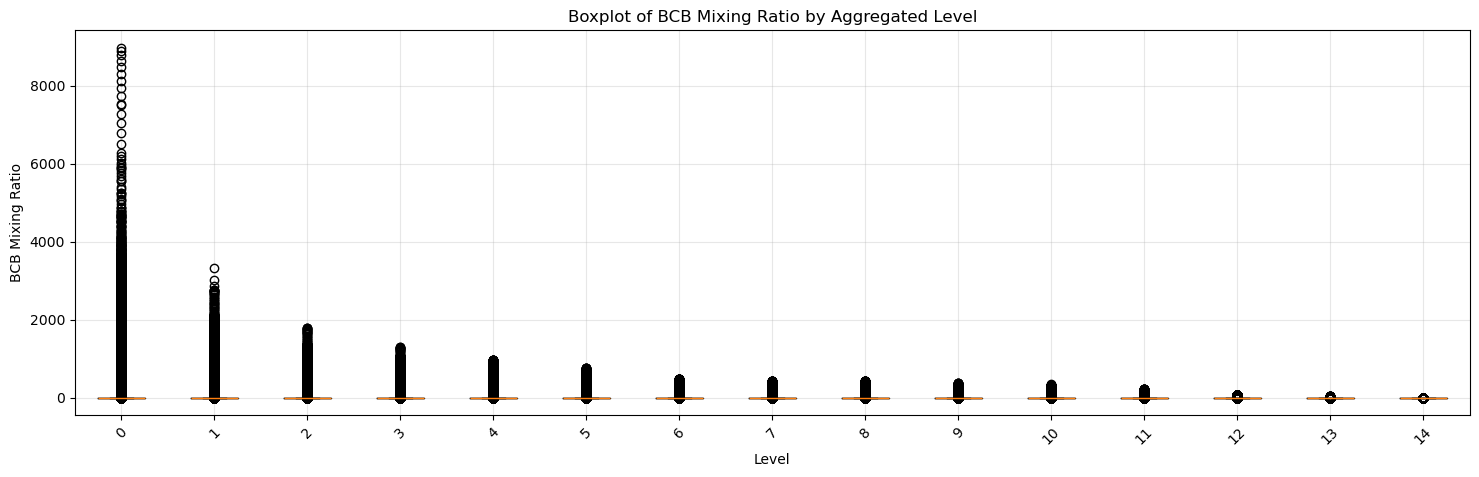

In [4]:
bcb_stacked = ds['bcb'].stack(sample=('time', 'lat', 'lon'))
bcb_stacked = bcb_stacked.transpose('sample', 'level')

# Create boxplot
fig, ax = plt.subplots(figsize=(18, 5))

box_plot = ax.boxplot(bcb_stacked, tick_labels=range(15), showfliers=True)
ax.set_xlabel('Level')
ax.set_ylabel('BCB Mixing Ratio')
ax.set_title('Boxplot of BCB Mixing Ratio by Aggregated Level')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.show()

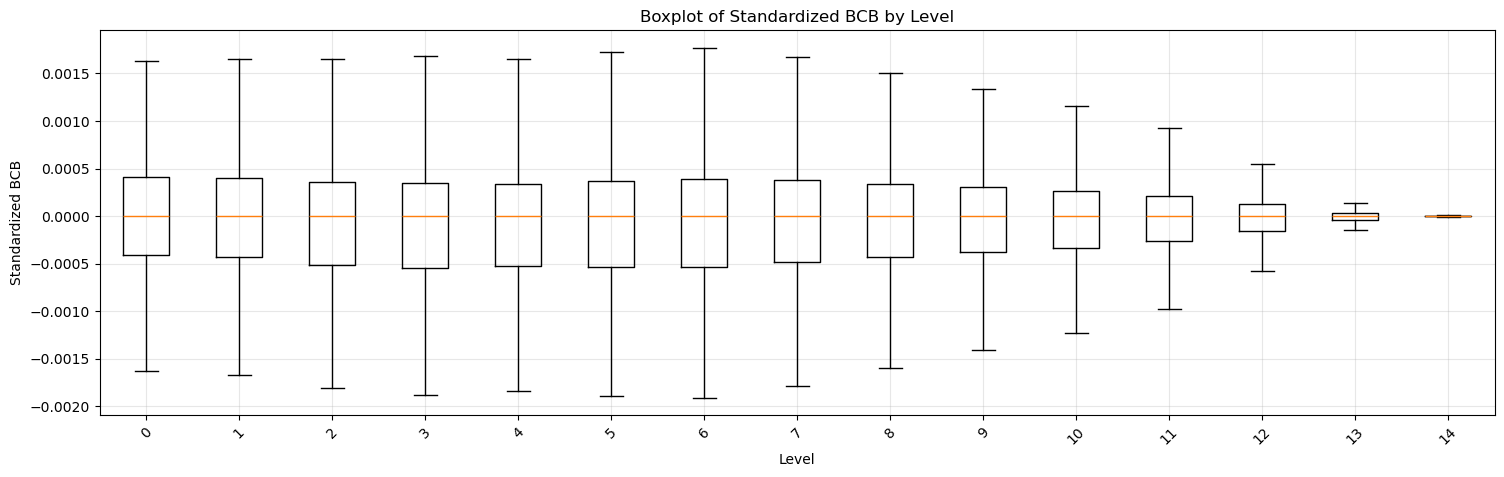

In [ ]:
tendency = ds.bcb.diff('time')  # bcb[t+1] - bcb[t]
tendency_stacked = tendency.stack(sample=('time', 'lat', 'lon'))
tendency_stacked = tendency_stacked.transpose('sample', 'level')

# Create boxplot
fig, ax = plt.subplots(figsize=(18, 5))

box_plot = ax.boxplot(tendency_stacked, tick_labels=range(15), showfliers=False)
ax.set_xlabel('Level')
ax.set_ylabel('BCB Tendency')
ax.set_title('Boxplot of BCB Tendency by Level')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.show()

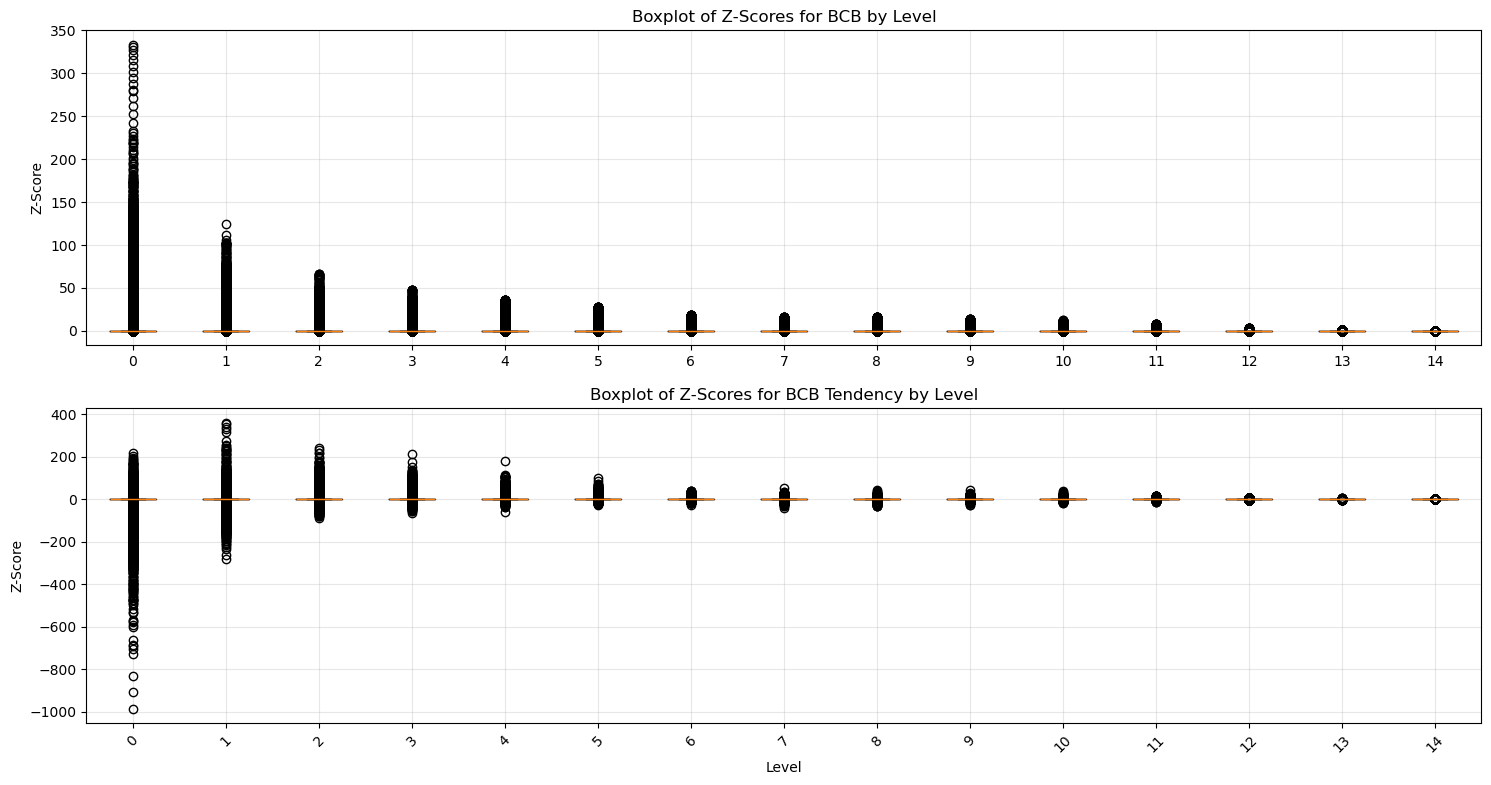

In [30]:
weights = np.cos(np.deg2rad(ds.lat))    

bcb_mean = ds.bcb.weighted(weights).mean(dim=("lat", "lon", "time"))
bcb_std = ds.bcb.weighted(weights).std(dim=("lat", "lon", "time"))

tendency_mean = tendency.weighted(weights).mean(dim=("lat", "lon", "time"))
tendency_std = tendency.weighted(weights).std(dim=("lat", "lon", "time"))

z_scores_bcb = (bcb_stacked - bcb_mean.isel(level=0)) / bcb_std.isel(level=0)
z_scores_tendency = (tendency_stacked - tendency_mean.isel(level=0)) / tendency_std.isel(level=0)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(18, 9))

box_plot = ax1.boxplot(z_scores_bcb, tick_labels=range(15), showfliers=True)
ax1.set_ylabel('Z-Score')
ax1.set_title('Boxplot of Z-Scores for BCB by Level')
ax1.grid(True, alpha=0.3)

box_plot = ax2.boxplot(z_scores_tendency, tick_labels=range(15), showfliers=True)
ax2.set_xlabel('Level')
ax2.set_ylabel('Z-Score')
ax2.set_title('Boxplot of Z-Scores for BCB Tendency by Level')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.show()

In [ ]:
for root, dirs, files in os.walk('/home/serfani/serfani_data1/E3OMA2010D'):
    
    sorted_files = sorted(files)
    list1 = [os.path.join(root, file) for file in sorted_files if file.split(".")[1] == 'aijh1E3oma']    
    list2 = [os.path.join(root, file) for file in sorted_files if file.split(".")[1] == 'aijlh1E3oma']   
    list3 = [os.path.join(root, file) for file in sorted_files if file.split(".")[1] == 'cijlh1E3oma']   
    list4 = [os.path.join(root, file) for file in sorted_files if file.split(".")[1] == 'taijlh1E3oma']  
    list5 = [os.path.join(root, file) for file in sorted_files if file.split(".")[1] == 'tNDaijh1E3oma'] 
    list6 = [os.path.join(root, file) for file in sorted_files if file.split(".")[1] == 'rijlh1E3oma']   

print(len(list1), len(list2), len(list3), len(list4), len(list5), len(list6))

1095 1095 1095 1095 1095 1095


In [8]:
ds1 = xr.open_mfdataset(list1[:30], data_vars='all') # ['axyp', 'prsurf', 'pblht_bp', 'shflx', 'lhflx']
ds2 = xr.open_mfdataset(list2[:30], data_vars='all') # ['axyp', 'u', 'v', 'omega', 'p_3d', 'z', 't', 'th', 'q']
# ds3 = xr.open_mfdataset(list3[:30], data_vars='all') # ['axyp', 'prec_3d_sum', 'mcuflx']
ds4 = xr.open_mfdataset(list4[:30], data_vars='all') # ['axyp', 'Clay', 'seasalt1', 'BCB', 'OCB', 'airmass']
ds5 = xr.open_mfdataset(list5[:30], data_vars='all') # ['axyp', 'Clay_emission', 'BCB_biomass_src', 'OCB_biomass_src']
# ds6 = xr.open_mfdataset(list6[:365], data_vars='all') # ['axyp', 'cfrad']

In [9]:
# Create new dataset
ds = xr.Dataset()

ds['bcb'] = ds4.BCB
ds['airmass'] = ds4.airmass

#  basic forecast variables (u, v, ω, T, q, and z)
ds['u'] = ds2.u
ds['v'] = ds2.v
ds['w'] = ds2.omega
ds['p'] = ds2.p_3d
ds['z'] = ds2.z
ds['t'] = ds2.t
ds['q'] = ds2.q
ds['th'] = ds2.th

ds['bcb_src'] = ds5.BCB_biomass_src
ds['pblh'] = ds1.pblht_bp
ds['cell_area'] = ds1.axyp.isel(time=0)  # lat x lon

ds

<xarray.Dataset> Size: 46GB
Dimensions:    (lon: 144, lat: 90, level: 62, time: 1440)
Coordinates:
  * lon        (lon) float32 576B -178.8 -176.2 -173.8 ... 173.8 176.2 178.8
  * lat        (lat) float32 360B -90.0 -87.0 -85.0 -83.0 ... 85.0 87.0 90.0
  * level      (level) float32 248B 1.0 2.0 3.0 4.0 5.0 ... 59.0 60.0 61.0 62.0
  * time       (time) object 12kB 2010-01-01 00:15:00 ... 2010-01-30 23:45:00
Data variables: (12/13)
    bcb        (time, level, lat, lon) float32 5GB dask.array<chunksize=(48, 62, 90, 144), meta=np.ndarray>
    airmass    (time, level, lat, lon) float32 5GB dask.array<chunksize=(48, 62, 90, 144), meta=np.ndarray>
    u          (time, level, lat, lon) float32 5GB dask.array<chunksize=(48, 62, 90, 144), meta=np.ndarray>
    v          (time, level, lat, lon) float32 5GB dask.array<chunksize=(48, 62, 90, 144), meta=np.ndarray>
    w          (time, level, lat, lon) float32 5GB dask.array<chunksize=(48, 62, 90, 144), meta=np.ndarray>
    p          (time, level, lat, lon) float32 5GB dask.array<chunksize=(48, 62, 90, 144), meta=np.ndarray>
    ...         ...
    t          (time, level, lat, lon) float32 5GB dask.array<chunksize=(48, 62, 90, 144), meta=np.ndarray>
    q          (time, level, lat, lon) float32 5GB dask.array<chunksize=(48, 62, 90, 144), meta=np.ndarray>
    th         (time, level, lat, lon) float32 5GB dask.array<chunksize=(48, 62, 90, 144), meta=np.ndarray>
    bcb_src    (time, lat, lon) float32 75MB dask.array<chunksize=(48, 90, 144), meta=np.ndarray>
    pblh       (time, lat, lon) float32 75MB dask.array<chunksize=(48, 90, 144), meta=np.ndarray>
    cell_area  (lat, lon) float32 52kB dask.array<chunksize=(90, 144), meta=np.ndarray>

In [10]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Converting a CFTimeIndex with dates from a non-standard calendar")
    
    ds['time'] = ds.indexes['time'].to_datetimeindex(time_unit='us')

    ds1['time'] = ds1.indexes['time'].to_datetimeindex(time_unit='us')
    ds2['time'] = ds2.indexes['time'].to_datetimeindex(time_unit='us')
    ds4['time'] = ds4.indexes['time'].to_datetimeindex(time_unit='us')
    ds5['time'] = ds5.indexes['time'].to_datetimeindex(time_unit='us')

### Horizontal Regridding Configurations

In [11]:
# Define target grid for regridding (2.8125° spacing)
new_grid = xr.Dataset(
    coords={
        "lat": np.linspace(-90 + 90 / 64, 90 - 90 / 64, 64),
        "lon": np.linspace(-180 + (180 / 128), 180 - (180 / 128), 128)
    }
)

In [12]:
def get_area_for_latlongrid(coords=None):

    latstep = np.abs(np.diff(coords["lat"])).mean()
    lonstep = np.abs(np.diff(coords["lon"])).mean()
    area = xr.DataArray(
        np.stack(
            len(coords["lon"])
            * [
                np.pi
                * 6.3781E6**2
                * np.abs(
                    np.sin(np.radians(coords["lat"] + latstep / 2))
                    - np.sin(np.radians(coords["lat"] - latstep / 2))
                )
                * lonstep
                / 180
            ],
            axis=-1,
        ),
        coords={"lat": coords["lat"], "lon": coords["lon"]},
        dims=("lat", "lon"),
    )

    return area

In [13]:
area = get_area_for_latlongrid(coords=new_grid.coords) 
print(f"Grid shape: {area.shape}")
print(f"Total area: {area.sum().values:.2e} m²")

Grid shape: (64, 128)
Total area: 5.11e+14 m²


In [14]:
print(f"Source lat range: {ds5['lat'].min().values:.15f} to {ds5['lat'].max().values:.15f}")
print(f"Target lat range: {area['lat'].min().values:.15f} to {area['lat'].max().values:.15f}")

print(f"Source lon range: {ds5['lon'].min().values:.15f} to {ds5['lon'].max().values:.15f}")
print(f"Target lon range: {area['lon'].min().values:.15f} to {area['lon'].max().values:.15f}")

Source lat range: -90.000000000000000 to 90.000000000000000
Target lat range: -88.593750000000000 to 88.593750000000000
Source lon range: -178.750000000000000 to 178.750000000000000
Target lon range: -178.593750000000000 to 178.593750000000000


### Vertical Regridding Configurations

In [10]:
plm = [979, 969, 959, 949, 939, 929, 919, 909, 899, 888.5, 877, 864, 848.5, 830, 808.5, 784, 756.5, 726, 692.5, 656, 
       616.5, 574, 531, 490, 451, 414, 379, 346, 315, 286, 259, 234, 211, 190, 171, 154, 139, 126, 115, 105, 95, 85, 
       75.5, 67, 59.5, 53, 47.5, 42.5, 37.5, 32.5, 27.5, 22.5, 17.5, 12.5, 7.81, 4.39, 2.47, 1.39, 0.781, 0.439, 0.247, 0.139]

l15_interp = [
    [0],                      # 979 hPa - Surface level
    [1, 2],                   # 969, 959 hPa - Planetary boundary layer
    [3, 4, 5],                # 949, 939, 929 hPa - Lower boundary layer
    [6, 7, 8],                # 919, 909, 899 hPa - Lower troposphere  
    [9, 10, 11],              # 888.5, 877, 864 hPa - Lower troposphere
    [12, 13, 14],             # 848.5, 830, 808.5 hPa - Mid-lower troposphere
    [15, 16, 17],             # 784, 756.5, 726 hPa - Mid troposphere
    [18],                     # 692.5 hPa - Mid troposphere
    [19],                     # 656 hPa - Mid troposphere
    [20],                     # 616.5 hPa - Mid troposphere
    [21],                     # 574 hPa - Mid-upper troposphere
    [22, 23],                 # 531, 490 hPa - Upper troposphere  
    [24, 25, 26, 27, 28, 29], # 451, 414, 379, 346, 315, 286 hPa - Upper troposphere/tropopause
    [30, 31, 32, 33, 34],     # 259, 234, 211, 190, 171 hPa - Lower stratosphere
    list(range(35, 62)),      # 154 hPa to 0.139 hPa - Middle and upper stratosphere/mesosphere
]

In [11]:
def create_new_pressure_levels(level_groups, original_pressure_levels=plm):
    """
    Create new pressure levels by combining original pressure levels based on the specified mapping.
    
    Parameters:
    - original_pressure_levels: List or array of the original pressure level values in hPa
    
    Returns:
    - new_pressure_levels: List of the new combined pressure levels in hPa
    - mapping: Dictionary mapping new pressure level indices to lists of original indices
    """
    
    # Calculate new pressure levels by averaging the original levels in each group
    new_pressure_levels = []
    for level_group in level_groups:
        if level_group:  # Check if the group is not empty
            # Extract the pressure values for this group
            group_pressures = [original_pressure_levels[idx] for idx in level_group]
            # Calculate the average pressure for this group
            avg_pressure = sum(group_pressures) / len(group_pressures)
            new_pressure_levels.append(round(avg_pressure, 1))
    
    # Create a mapping dictionary for reference
    mapping = {i: group for i, group in enumerate(level_groups)}
    
    return new_pressure_levels, mapping

In [12]:
l15_pressures = create_new_pressure_levels(l15_interp, original_pressure_levels=plm)[0]

## Horizontal Regridding

### BCB Surface Fluxes
BCB surface fluxes are typically expressed as an intensive quantity (mol/m²/s or kg/m²/s), but they should use conservative regridding to ensure mass conservation. This is a special case where an intensive quantity benefits from conservative regridding due to mass conservation requirements.

In [18]:
regridder = xe.Regridder(ds['bcb_src'], area, 'conservative', periodic=True)
regridded_bcb_src = regridder(ds['bcb_src'], keep_attrs=True)

/home/serfani/miniforge3/envs/nesm/lib/python3.12/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


### BCB mixing ratio
Current unit: 10⁻¹¹ kg BCB / kg air (intensive)

Air mass density: kg air / m² (intensive - mass per unit area)

**Step-by-step Logic:**

Step 1 - Air mass density (kg/m²) × Cell area (m²) = Total air mass (kg per cell)

Step 2 - BCB mixing ratio (kg BCB/kg air) × Total air mass (kg air per cell) = Total BCB mass (kg BCB per cell)

In [50]:
# Create a copy of the dataset for our outputs
ds_extensive = xr.Dataset()

# Add grid cell area to the dataset
ds_extensive["cell_area"] = ds['cell_area']

# Convert air mass to extensive (total kg per grid cell)
ds_extensive["airmass_total"] = ds['airmass'] * ds_extensive["cell_area"] # kg / m² * m² = kg
ds_extensive.airmass_total.attrs = {
    "units": "kg", 
    "long_name": "Total air mass per grid cell"
}

# Convert BCB mixing ratio to extensive (total kg per grid cell)
ds_extensive["bcb_total"] = ds['bcb'] * 1E-11 * ds_extensive.airmass_total # kg/kg * kg = kg
ds_extensive.bcb_total.attrs = {
    "units": "kg", 
    "long_name": "Total BCB mass per grid cell"
}

In [51]:
# Setup regridder
regridder = xe.Regridder(ds_extensive, area, 'conservative', periodic=True)

# Apply regridding to each variable separately
ds_regrid = xr.Dataset()

# Only regrid the extensive variables (not cell_area)
for var in ["airmass_total", "bcb_total"]:
    # Divide by source cell area, regrid, multiply by target area
    tmp = regridder(ds_extensive[var] / ds_extensive['cell_area'], keep_attrs=True) * area # kg/m² -> kg/cell
    
    # Normalize to conserve global sum
    ds_regrid[var] = (
        tmp / tmp.sum(["lat", "lon"]) * ds_extensive[var].sum(["lat", "lon"])
    )

# Add the target grid area to the output dataset
ds_regrid["cell_area"] = area
ds_regrid["cell_area"].attrs = ds["cell_area"].attrs

/home/serfani/miniforge3/envs/nesm/lib/python3.12/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


In [52]:
# Calculate densities (kg/m²)
bcb_density = ds_regrid['bcb_total'] / area
airmass_density = ds_regrid['airmass_total'] / area


# Convert from mass density back to mixing ratio
ds_regrid['bcb'] = xr.where(
    airmass_density > 0,
    bcb_density / airmass_density / 1E-11,
    0  # or np.nan
)

# Add appropriate attributes to match original data
ds_regrid.bcb.attrs = {
    "units": "10^-11 kg / kg air",
    "long_name": "BCB mixing ratio"
}

ds_regrid['airmass'] = airmass_density
ds_regrid.airmass.attrs = {
    "units": "kg m-2",
    "long_name": "air mass density"
}

### Intensive Variables

In [17]:
intensive_vars =['u', 'v', 'p', 'z', 't', 'th', 'q', 'pblh']

regridder = xe.Regridder(ds[intensive_vars], area, 'bilinear', periodic=True)
regridded_intensive_vars = regridder(ds[intensive_vars], keep_attrs=True)

In [18]:
# For intensive variables that are in the regridded_intensive_vars dictionary
for var in ['u', 'v', 'p', 'z', 't', 'th', 'q', 'pblh']:
    ds_regrid[var] = regridded_intensive_vars[var]
    ds_regrid[var].attrs = ds[var].attrs

# For bcb_src which is handled separately
ds_regrid['bcb_src'] = regridded_bcb_src
ds_regrid.bcb_src.attrs = ds['bcb_src'].attrs

ds_regrid = ds_regrid.drop_vars(['airmass_total', 'bcb_total'])

ds_regrid

<xarray.Dataset> Size: 32GB
Dimensions:    (level: 62, time: 1440, lat: 64, lon: 128)
Coordinates:
  * level      (level) float32 248B 1.0 2.0 3.0 4.0 5.0 ... 59.0 60.0 61.0 62.0
  * time       (time) datetime64[us] 12kB 2010-01-01T00:15:00 ... 2010-01-30T...
  * lat        (lat) float64 512B -88.59 -85.78 -82.97 ... 82.97 85.78 88.59
  * lon        (lon) float64 1kB -178.6 -175.8 -173.0 ... 173.0 175.8 178.6
Data variables:
    cell_area  (lat, lon) float64 66kB 2.405e+09 2.405e+09 ... 2.405e+09
    bcb        (time, level, lat, lon) float64 6GB dask.array<chunksize=(48, 62, 64, 128), meta=np.ndarray>
    airmass    (time, level, lat, lon) float64 6GB dask.array<chunksize=(48, 62, 64, 128), meta=np.ndarray>
    u          (time, level, lat, lon) float32 3GB dask.array<chunksize=(48, 62, 64, 128), meta=np.ndarray>
    v          (time, level, lat, lon) float32 3GB dask.array<chunksize=(48, 62, 64, 128), meta=np.ndarray>
    p          (time, level, lat, lon) float32 3GB dask.array<chunksize=(48, 62, 64, 128), meta=np.ndarray>
    z          (time, level, lat, lon) float32 3GB dask.array<chunksize=(48, 62, 64, 128), meta=np.ndarray>
    t          (time, level, lat, lon) float32 3GB dask.array<chunksize=(48, 62, 64, 128), meta=np.ndarray>
    th         (time, level, lat, lon) float32 3GB dask.array<chunksize=(48, 62, 64, 128), meta=np.ndarray>
    q          (time, level, lat, lon) float32 3GB dask.array<chunksize=(48, 62, 64, 128), meta=np.ndarray>
    pblh       (time, lat, lon) float32 47MB dask.array<chunksize=(48, 64, 128), meta=np.ndarray>
    bcb_src    (time, lat, lon) float32 47MB dask.array<chunksize=(48, 64, 128), meta=np.ndarray>

### Evaluation of Regredding on Horizontal Domain

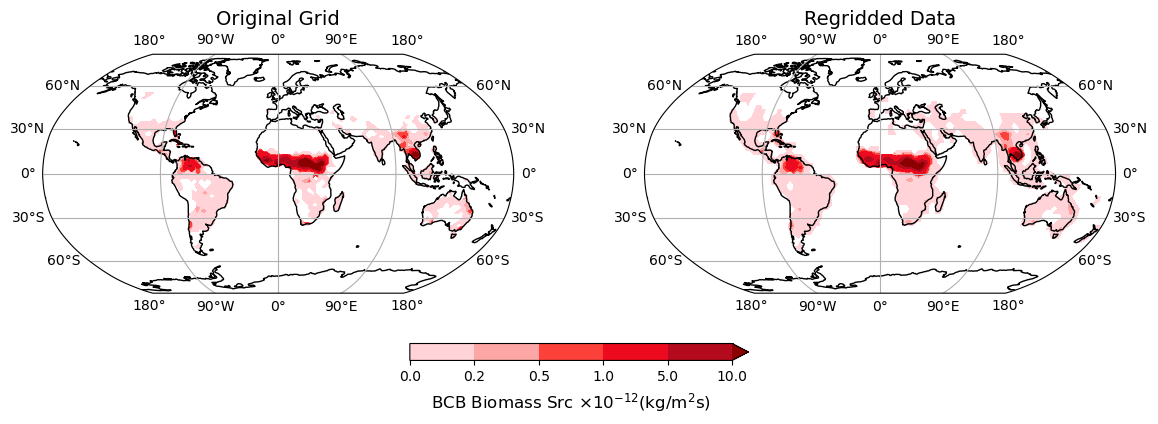

In [26]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 4), subplot_kw={'projection': ccrs.Robinson()}, constrained_layout=True)

# Original data (left subplot)
ax1 = axes[0]
lon1, lat1 = np.meshgrid(ds5['lon'], ds5['lat'])
data1 = ds5['BCB_biomass_src'].mean(dim='time').compute()  # Add .compute() if using dask
data1 = np.where(data1 <= 0.0, np.nan, data1)
ax1.coastlines()

colors = [(0.0, 'mistyrose'), (0.025, 'pink'), (0.05, 'salmon'), (0.1, 'red'), (0.5, 'crimson'), (1.0, 'darkred')]
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)

im1 = ax1.contourf(
    lon1, lat1, data1,
    transform=ccrs.PlateCarree(),
    levels=[0, 0.25, 0.5, 1.0, 5.0, 10], 
    cmap=cmap, extend='max'
)

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl1.xlocator = mticker.FixedLocator([-180, -90, 0, 90, 180])
ax1.set_title('Original Grid', fontsize=14)

# Regridded data (right subplot)
ax2 = axes[1]
lon2, lat2 = np.meshgrid(ds_regrid['lon'], ds_regrid['lat'])  # Replace with your regridded data variable names
data2 = ds_regrid['bcb_src'].mean(dim='time').compute()  # Add .compute() if using dask
data2 = np.where(data2 <= 0.0, np.nan, data2)
ax2.coastlines()

im2 = ax2.contourf(
    lon2, lat2, data2,
    transform=ccrs.PlateCarree(),
    levels=[0, 0.25, 0.5, 1.0, 5.0, 10], 
    cmap=cmap, extend='max'
)

gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl2.xlocator = mticker.FixedLocator([-180, -90, 0, 90, 180])
ax2.set_title('Regridded Data', fontsize=14)

# Add a shared colorbar at the bottom
cbar = plt.colorbar(im1, ax=axes, orientation='horizontal', pad=0.1, shrink=0.3)
cbar.set_label(r'BCB Biomass Src $ \times 10^{-12} (\mathrm{kg} / \mathrm{m}^{2} \mathrm{s}$)', rotation=0, labelpad=5, fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.show()


Statistical Comparison:
Original Grid - Count: 12960, Mean: 0.059062, Std: 0.876324
Regridded     - Count: 8192, Mean: 0.059067, Std: 0.748383
Difference in means: 0.000005
Relative difference: 0.009%
Kolmogorov-Smirnov test: statistic=0.060432, p-value=0.000000

Q-Q Plot Interpretation:
Linear fit: y = 0.816x + 0.009985
R² = 0.9698
⚠ Distributions show notable differences


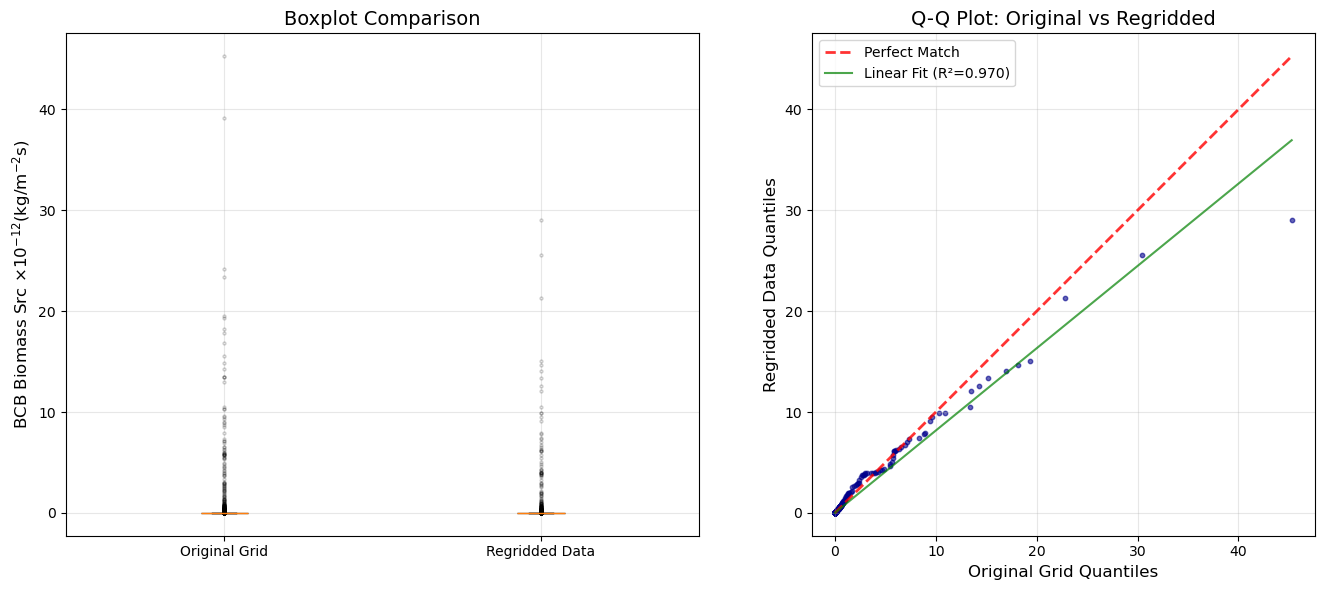

In [21]:

# Prepare the data (same as above)
data1 = ds5['BCB_biomass_src'].mean(dim='time').compute()
data2 = ds_regrid['bcb_src'].mean(dim='time').compute()

data1_clean = data1.values.flatten()
data2_clean = data2.values.flatten()

# data1_clean = data1_clean[(data1_clean > 0) & (~np.isnan(data1_clean))]
# data2_clean = data2_clean[(data2_clean > 0) & (~np.isnan(data2_clean))]

# Create subplot with boxplot and Q-Q plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
box_data = [data1_clean, data2_clean]
labels = ['Original Grid', 'Regridded Data']

bp = ax1.boxplot(box_data, tick_labels=labels, patch_artist=True, 
                 showfliers=True, flierprops=dict(marker='o', markersize=2, alpha=0.2))

colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.grid(True, alpha=0.3)
ax1.set_ylabel(r'BCB Biomass Src $ \times 10^{-12} (\mathrm{kg} / \mathrm{m}^{-2} \mathrm{s}$)', fontsize=12)
ax1.set_title('Boxplot Comparison', fontsize=14)

# Q-Q plot
def qq_plot(x, y, ax, labels=None):
    """Create a Q-Q plot comparing two datasets"""
    # Calculate quantiles
    n = min(len(x), len(y))
    quantiles = np.linspace(0, 1, n)
    
    x_quantiles = np.quantile(x, quantiles)
    y_quantiles = np.quantile(y, quantiles)
    
    # Plot the Q-Q plot
    ax.scatter(x_quantiles, y_quantiles, alpha=0.6, s=10, color='darkblue')
    
    # Add the 1:1 line (perfect match)
    min_val = min(np.min(x_quantiles), np.min(y_quantiles))
    max_val = max(np.max(x_quantiles), np.max(y_quantiles))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2, label='Perfect Match')
    
    # Calculate and plot linear fit
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_quantiles, y_quantiles)
    fit_line = slope * x_quantiles + intercept
    ax.plot(x_quantiles, fit_line, 'g-', alpha=0.7, linewidth=1.5, 
            label=f'Linear Fit (R²={r_value**2:.3f})')
    
    return slope, intercept, r_value

# Create Q-Q plot
slope, intercept, r_value = qq_plot(data1_clean, data2_clean, ax2)

ax2.set_xlabel('Original Grid Quantiles', fontsize=12)
ax2.set_ylabel('Regridded Data Quantiles', fontsize=12)
ax2.set_title('Q-Q Plot: Original vs Regridded', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Make axes equal for better interpretation
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()

# Statistical tests and Q-Q interpretation
ks_stat, ks_pvalue = stats.ks_2samp(data1_clean, data2_clean)
print("\nStatistical Comparison:")
print(f"Original Grid - Count: {len(data1_clean)}, Mean: {np.mean(data1_clean):.6f}, Std: {np.std(data1_clean):.6f}")
print(f"Regridded     - Count: {len(data2_clean)}, Mean: {np.mean(data2_clean):.6f}, Std: {np.std(data2_clean):.6f}")
print(f"Difference in means: {np.mean(data2_clean) - np.mean(data1_clean):.6f}")
print(f"Relative difference: {((np.mean(data2_clean) - np.mean(data1_clean))/np.mean(data1_clean))*100:.3f}%")
print(f"Kolmogorov-Smirnov test: statistic={ks_stat:.6f}, p-value={ks_pvalue:.6f}")

print(f"\nQ-Q Plot Interpretation:")
print(f"Linear fit: y = {slope:.3f}x + {intercept:.6f}") # Slope < 1 means the regridded data has LESS variability (compressed range)
print(f"R² = {r_value**2:.4f}")

if abs(slope - 1.0) < 0.05 and abs(intercept) < np.mean(data1_clean) * 0.01:
    print("✓ Distributions are very similar (slope ≈ 1, intercept ≈ 0)")
elif abs(slope - 1.0) < 0.1:
    print("~ Distributions are similar with minor differences")
else:
    print("⚠ Distributions show notable differences")

plt.show()

Global Mean Time Series Comparison:
Original Grid - Time average: 0.091267
Regridded    - Time average: 0.091207
Mean difference: -0.000060
Relative difference: -0.065%
Standard deviation of differences: 0.000004
Maximum absolute difference: 0.000069
Correlation coefficient: 1.000000
Root Mean Square Error: 0.000060


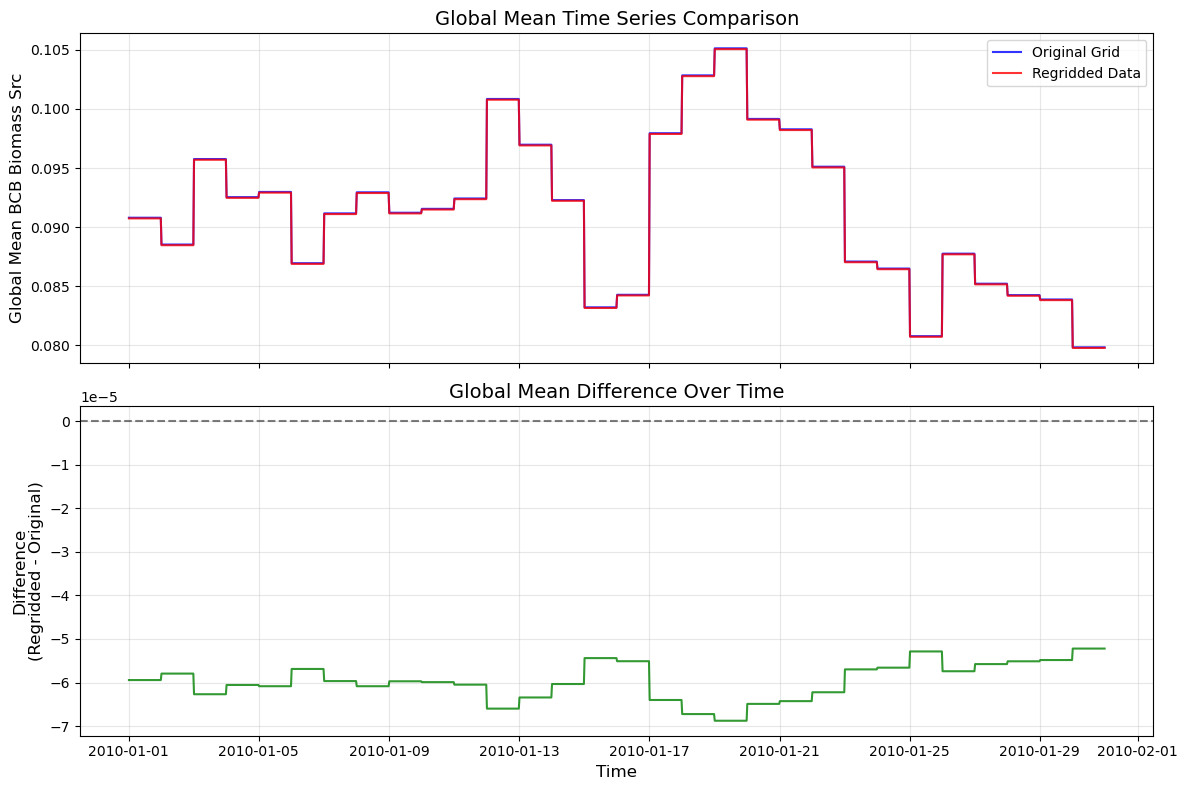

In [37]:
# Calculate area weights
weights_original = np.cos(np.deg2rad(ds5.lat))
weights_regridded = np.cos(np.deg2rad(ds_regrid.lat))

global_mean_original = ds5['BCB_biomass_src'].weighted(weights_original).mean(dim=("lat", "lon"))
global_mean_regridded = ds_regrid['bcb_src'].weighted(weights_regridded).mean(dim=("lat", "lon"))

# Create time series comparison plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Time series comparison
ax1.plot(ds_regrid.time, global_mean_original, 'b-', label='Original Grid', alpha=0.8, linewidth=1.5)
ax1.plot(ds_regrid.time, global_mean_regridded, 'r-', label='Regridded Data', alpha=0.8, linewidth=1.5)
ax1.set_ylabel(r'Global Mean BCB Biomass Src', fontsize=12)
ax1.set_title('Global Mean Time Series Comparison', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Difference time series
difference = global_mean_regridded - global_mean_original
ax2.plot(ds_regrid.time, difference, 'g-', alpha=0.8, linewidth=1.5)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Difference\n(Regridded - Original)', fontsize=12)
ax2.set_title('Global Mean Difference Over Time', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Calculate and print statistics
mean_original = float(global_mean_original.mean())
mean_regridded = float(global_mean_regridded.mean())
mean_difference = float(difference.mean())
std_difference = float(difference.std())
max_abs_diff = float(np.abs(difference).max())

print("Global Mean Time Series Comparison:")
print(f"Original Grid - Time average: {mean_original:.6f}")
print(f"Regridded    - Time average: {mean_regridded:.6f}")
print(f"Mean difference: {mean_difference:.6f}")
print(f"Relative difference: {(mean_difference/mean_original)*100:.3f}%")
print(f"Standard deviation of differences: {std_difference:.6f}")
print(f"Maximum absolute difference: {max_abs_diff:.6f}")

# Correlation analysis
correlation = np.corrcoef(global_mean_original, global_mean_regridded)[0, 1]
print(f"Correlation coefficient: {correlation:.6f}")

# Root Mean Square Error
rmse = np.sqrt(np.mean(difference**2))
print(f"Root Mean Square Error: {float(rmse):.6f}")

plt.show()

In [39]:
# Verify the conversion
print("Verification:")
print(f"Original BCB mixing ratio  - Mean: {ds4.BCB.mean().values:.6f}, Std: {ds4.BCB.std().values:.6f}")
print(f"Regridded BCB mixing ratio - Mean: {ds_regrid.bcb.mean().values:.6f}, Std: {ds_regrid.bcb.std().values:.6f}")

# Now you can access the mixing ratio directly from ds_regrid
print(f"\nds_regrid now contains BCB mixing ratio with shape: {ds_regrid.bcb.shape}")
print(f"Available variables in ds_regrid: {list(ds_regrid.data_vars.keys())}")

Verification:
Original BCB mixing ratio  - Mean: 0.348423, Std: 5.504931
Regridded BCB mixing ratio - Mean: 0.348885, Std: 5.074767

ds_regrid now contains BCB mixing ratio with shape: (1440, 62, 64, 128)
Available variables in ds_regrid: ['cell_area', 'bcb', 'airmass', 'u', 'v', 'w', 'p', 'z', 't', 'th', 'q', 'pblh', 'bcb_src']


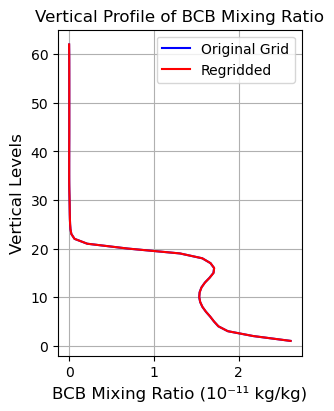

In [53]:
# grid weights
weights_original = np.cos(np.deg2rad(ds4.lat))
weights_regridded = np.cos(np.deg2rad(ds_regrid.lat))

# Calculate weighted means separately
ds_avg_original = ds4.BCB.weighted(weights_original).mean(dim=("lat", "lon", "time"))
ds_avg_regridded = ds_regrid.bcb.weighted(weights_regridded).mean(dim=("lat", "lon", "time"))

# Set consistent font sizes
LABEL_SIZE = 12
TICK_SIZE = 10
LEGEND_SIZE = 10

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(3, 4), constrained_layout=True)

# Plot both vertical profiles
ds_avg_original.plot(ax=ax, y='level', yincrease=True, label='Original Grid', color='blue')
ds_avg_regridded.plot(ax=ax, y='level', yincrease=True, label='Regridded', color='red')

# Set axis labels with font size
ax.set_xlabel('BCB Mixing Ratio (10⁻¹¹ kg/kg)', fontsize=LABEL_SIZE)
ax.set_ylabel('Vertical Levels', fontsize=LABEL_SIZE)

# Adjust tick label font sizes
ax.tick_params(axis='x', labelsize=TICK_SIZE)
ax.tick_params(axis='y', labelsize=TICK_SIZE)

ax.grid()
plt.legend(fontsize=LEGEND_SIZE)
plt.title('Vertical Profile of BCB Mixing Ratio', fontsize=LABEL_SIZE)

plt.show()

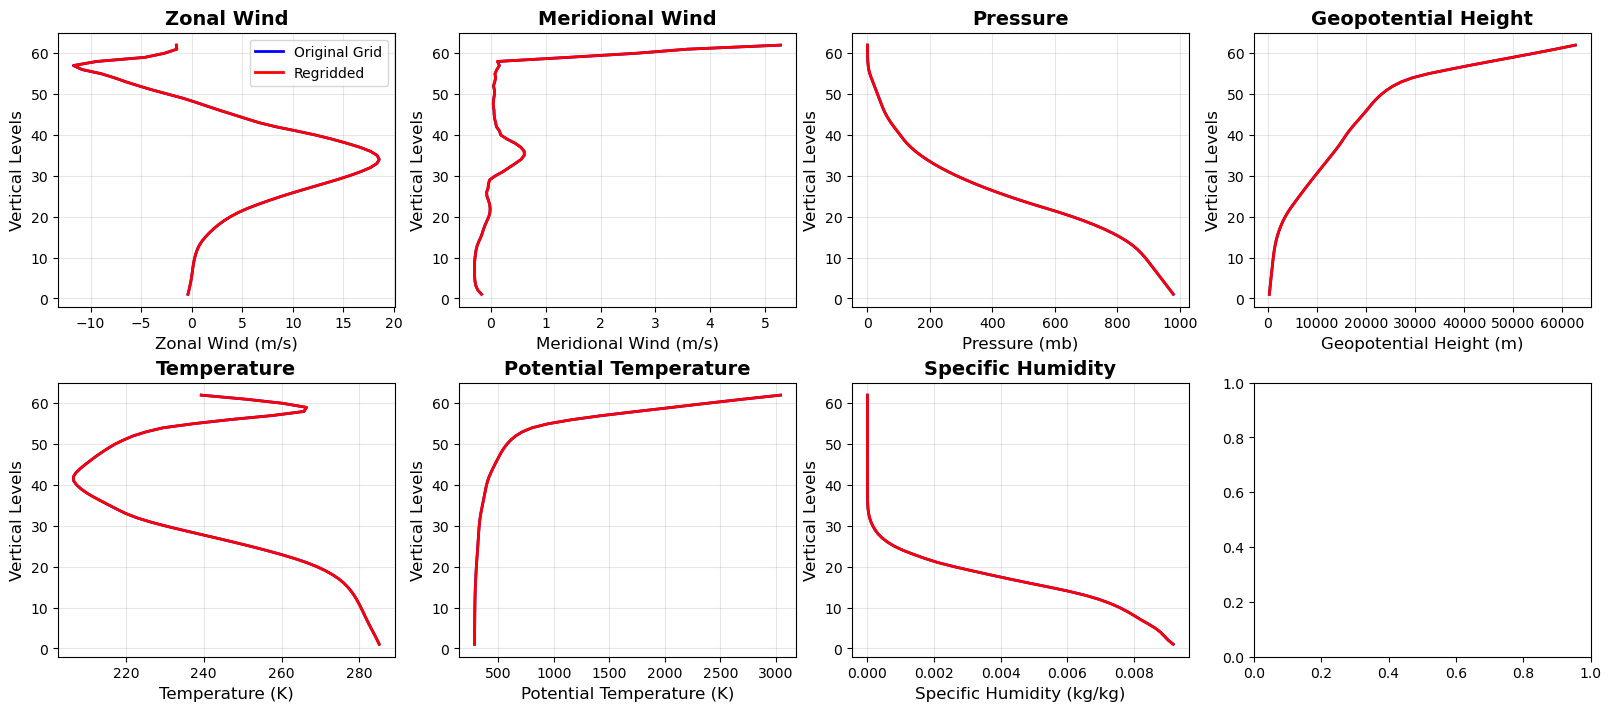

In [24]:
# Define variable mappings and nice names
variable_mapping = {
    'u': ('u', 'Zonal Wind'),
    'v': ('v', 'Meridional Wind'), 
    'p_3d': ('p', 'Pressure'),
    'z': ('z', 'Geopotential Height'),
    't': ('t', 'Temperature'),
    'th': ('th', 'Potential Temperature'),
    'q': ('q', 'Specific Humidity')
}

# Grid weights
weights_original = np.cos(np.deg2rad(ds2.lat))
weights_regridded = np.cos(np.deg2rad(ds_regrid.lat))

# Set consistent font sizes
LABEL_SIZE = 12
TICK_SIZE = 10
LEGEND_SIZE = 10
TITLE_SIZE = 14

# Create subplots - 4 columns, 2 rows
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for i, (orig_var, (regrid_var, nice_name)) in enumerate(variable_mapping.items()):
    ax = axes[i]
    
    # Calculate weighted means
    ds_avg_original = ds2[orig_var].weighted(weights_original).mean(dim=("lat", "lon", "time"))
    ds_avg_regridded = ds_regrid[regrid_var].weighted(weights_regridded).mean(dim=("lat", "lon", "time"))
    
    # Plot both vertical profiles
    ds_avg_original.plot(ax=ax, y='level', yincrease=True, label='Original Grid', color='blue', linewidth=2)
    ds_avg_regridded.plot(ax=ax, y='level', yincrease=True, label='Regridded', color='red', linewidth=2)
    
    # Get units from the original dataset (you can change to regridded if preferred)
    try:
        units = ds2[orig_var].attrs.get('units', 'Unknown units')
    except:
        units = 'Unknown units'
    
    # Set labels and formatting
    ax.set_xlabel(f'{nice_name} ({units})', fontsize=LABEL_SIZE)
    ax.set_ylabel('Vertical Levels', fontsize=LABEL_SIZE)
    ax.set_title(f'{nice_name}', fontsize=TITLE_SIZE, fontweight='bold')
    
    # Adjust tick label font sizes
    ax.tick_params(axis='x', labelsize=TICK_SIZE)
    ax.tick_params(axis='y', labelsize=TICK_SIZE)
    
    # Add grid and legend
    ax.grid(True, alpha=0.3)
    if i == 0:  # Only add legend to first subplot to avoid clutter
        ax.legend(fontsize=LEGEND_SIZE, loc='best')

# Add overall title
# fig.suptitle('Vertical Profiles: Original vs Regridded Data', fontsize=16, fontweight='bold')

plt.show()

## Vertical Regridding

# Mass-Weighted Vertical Averaging: A Simple Example

Let me illustrate this with a concrete example using water bottles of different sizes to represent atmospheric layers:

## Scenario: Calculating Average Sugar Concentration Across Water Bottles

Imagine we have 3 water bottles with different amounts of water and sugar concentrations:

| Bottle | Water Amount | Sugar Concentration | Total Sugar |
|--------|-------------|---------------------|-------------|
| Top    | 200 ml      | 5% (5g/100ml)       | 10g         |
| Middle | 500 ml      | 10% (10g/100ml)     | 50g         |
| Bottom | 300 ml      | 15% (15g/100ml)     | 45g         |

Now we want to combine these bottles into one container and determine the resulting sugar concentration.

## Step-by-Step Process (Matching the Code):

### 1. Calculate Total Water Amount (equivalent to `airmass.sum()`)
Total water = 200ml + 500ml + 300ml = 1000ml

```python
# Code equivalent
ds_aggregated["airmass"] = vertical_ds.airmass.isel(level=level).sum("level")
```

### 2. Calculate Total Sugar Amount (equivalent to `(co2massmix * airmass).sum()`)
For each bottle, multiply concentration by water amount:
- Top bottle: 5% × 200ml = 10g sugar
- Middle bottle: 10% × 500ml = 50g sugar
- Bottom bottle: 15% × 300ml = 45g sugar

Total sugar = 10g + 50g + 45g = 105g

```python
# Code equivalent - first part
(vertical_ds.co2massmix * vertical_ds.airmass).isel(level=level).sum("level")
```

### 3. Calculate Average Concentration (equivalent to dividing by total airmass)
Average sugar concentration = Total sugar / Total water
                            = 105g / 1000ml
                            = 10.5%

```python
# Code equivalent - complete calculation
ds_aggregated["co2massmix"] = (
    vertical_ds.co2massmix * vertical_ds.airmass
).isel(level=level).sum("level") / ds_aggregated.airmass
```

## Why This Is Important

If we had simply averaged the concentrations (5% + 10% + 15%)/3 = 10%, we would get the wrong answer.

Mass-weighted averaging recognizes that the bottle with 500ml (middle bottle) contributes more to the final mixture than the 200ml bottle (top bottle). 

This is particularly important for atmospheric modeling where different vertical levels contain different amounts of air.

This approach ensures that when you vertically aggregate CO2 concentrations across multiple atmospheric levels, you properly account for the different air masses at each level, maintaining mass conservation principles.

In [7]:
def vertical_aggregation(ds, levels):

    vertical_ds = ds[[v for v in ds if "level" in ds[v].dims]]
    all_aggregated_ds = []
    
    for i, level in enumerate(levels):

        if len(level) > 1:
            # Get pressures for the levels to aggregate
            pressures = vertical_ds.p.isel(level=level)
            
            # Estimate pressure thickness from spacing between mid-layer pressures
            # For interior layers: use half the distance to each neighbor
            # For edge layers: use full distance to the single neighbor
            pressure_thickness = []
            
            for j in range(len(level)):
                if j == 0:  # First layer
                    if len(level) > 1:
                        # Use half distance to next layer, doubled
                        thickness = abs(pressures.isel(level=1) - pressures.isel(level=0))
                    else:
                        thickness = pressures.isel(level=0)  # Fallback for single layer
                elif j == len(level) - 1:  # Last layer
                    # Use half distance to previous layer, doubled
                    thickness = abs(pressures.isel(level=j-1) - pressures.isel(level=j))
                else:  # Interior layers
                    # Use half distance to each neighbor
                    thickness = (abs(pressures.isel(level=j-1) - pressures.isel(level=j)) + 
                               abs(pressures.isel(level=j) - pressures.isel(level=j+1))) / 2
                
                pressure_thickness.append(thickness)
            
            pressure_thickness = xr.concat(pressure_thickness, dim='level')
            pressure_weights = pressure_thickness / pressure_thickness.sum("level")

            ds_aggregated = (vertical_ds.isel(level=level) * pressure_weights).sum("level")
            
            # Set aggregated mid-layer pressure (pressure-weighted)
            # ds_aggregated["p"] = (pressures * pressure_weights).sum("level")

            ds_aggregated["airmass"] = vertical_ds.airmass.isel(level=level).sum("level")
            ds_aggregated["bcb"] = (
                vertical_ds.bcb * vertical_ds.airmass
            ).isel(level=level).sum("level") / ds_aggregated.airmass

            ds_aggregated = ds_aggregated.assign_coords(dict(level=[i]))
        else:
            ds_aggregated = vertical_ds.isel(level=level).assign_coords(dict(level=[i]))

        all_aggregated_ds.append(ds_aggregated)

    ds_aggregated = xr.concat(all_aggregated_ds, "level", data_vars='all')

    for v in ds:
        if "level" not in ds[v].dims:
            ds_aggregated[v] = ds[v]

    return ds_aggregated

In [8]:
ds_vregrid = vertical_aggregation(ds, levels=l15_interp)
ds_vregrid = ds_vregrid.chunk(dict(time=-1, lat=-1, lon=-1, level=-1))

In [12]:
ds['level'] = plm
ds_vregrid["level"] = l15_pressures

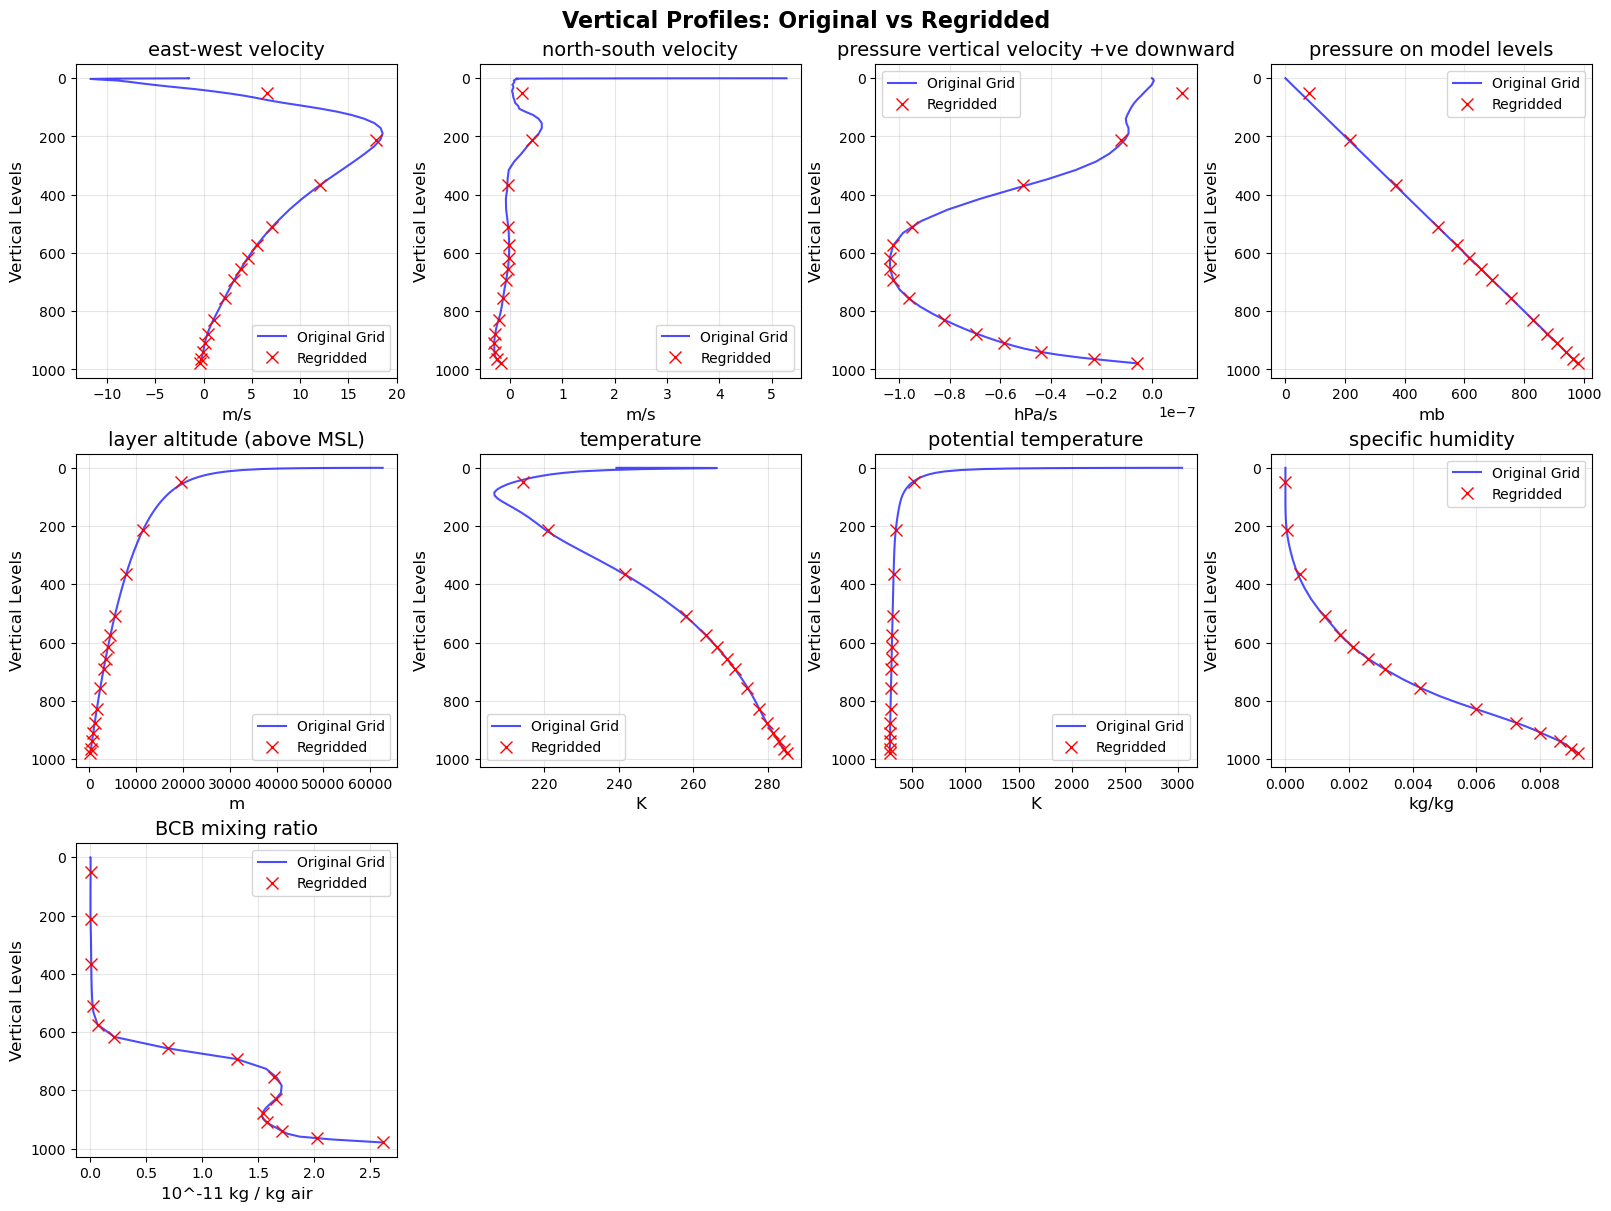

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_vertical_profiles(ds, ds_vregrid, variables=None):
    """
    Plot vertical profiles for all 3D variables in the datasets.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Original dataset
    ds_vregrid : xarray.Dataset
        Vertically regridded dataset
    variables : list, optional
        List of variables to plot. If None, all 3D variables are plotted.
    """
    # Identify all 3D variables if not specified
    if variables is None:
        variables = []
        for var in ds.data_vars:
            if 'level' in ds[var].dims and 'lat' in ds[var].dims and 'lon' in ds[var].dims:
                variables.append(var)
    
    # Add BCB if it exists and not already in list
    if 'bcb' in ds.data_vars and 'bcb' not in variables:
        variables.append('bcb')
    
    # Create variable mapping with nice names
    var_metadata = {
        'u': ('Zonal Wind', 'm/s'),
        'v': ('Meridional Wind', 'm/s'), 
        'w': ('Vertical Velocity', 'Pa/s'),
        'p': ('Pressure', 'hPa'),
        'z': ('Geopotential Height', 'm'),
        't': ('Temperature', 'K'),
        'th': ('Potential Temperature', 'K'),
        'q': ('Specific Humidity', 'kg/kg'),
        'bcb': ('BCB Mixing Ratio', '10⁻¹¹ kg/kg')
    }
    
    # Grid weights
    w_orig = np.cos(np.deg2rad(ds.lat))
    w_regrid = np.cos(np.deg2rad(ds_vregrid.lat))
    
    # Set consistent font sizes
    LABEL_SIZE = 12
    TICK_SIZE = 10
    LEGEND_SIZE = 10
    TITLE_SIZE = 14
    
    # Create figure
    n_vars = len(variables)
    n_cols = min(4, n_vars)
    n_rows = int(np.ceil(n_vars / n_cols))
    
    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(4*n_cols, 4*n_rows), 
                             constrained_layout=True)
    
    # Handle single subplot case
    if n_vars == 1:
        axes = np.array([axes])
    
    axes = axes.flatten()
    
    # Loop through variables and create plots
    for i, var in enumerate(variables):
        if i < len(axes):
            ax = axes[i]
            
            # Find corresponding variable in regridded dataset (handle name differences)
            regrid_var = var
            if var == 'omega':
                regrid_var = 'w'
            elif var == 'p_3d':
                regrid_var = 'p'
            
            # Calculate weighted means
            if var in ds.data_vars:
                ds_avg = ds[var].weighted(w_orig).mean(dim=("lat", "lon", "time"))
                
                # Get variable attributes
                try:
                    units = ds[var].attrs.get('units', var_metadata.get(var, ('', ''))[1])
                    nice_name = ds[var].attrs.get('long_name', var_metadata.get(var, (var, ''))[0])
                except:
                    units = var_metadata.get(var, ('', ''))[1]
                    nice_name = var_metadata.get(var, (var, ''))[0]
                
                # Plot original data
                ds_avg.plot(ax=ax, y='level', yincrease=False, 
                           label='Original Grid', color='blue', alpha=0.7)
            
            # Plot regridded data if available
            if regrid_var in ds_vregrid.data_vars:
                ds_vr_avg = ds_vregrid[regrid_var].weighted(w_regrid).mean(dim=("lat", "lon", "time"))
                
                # Plot regridded with markers to distinguish vertical levels
                ds_vr_avg.plot(ax=ax, y='level', yincrease=False, 
                              label='Regridded', color='red',
                              marker='x', markersize=8, linewidth=1.5, linestyle='')
            
            # Set labels and formatting
            if units:
                ax.set_xlabel(f'{units}', fontsize=LABEL_SIZE)
            ax.set_ylabel('Vertical Levels', fontsize=LABEL_SIZE)
            ax.set_title(f'{nice_name}', fontsize=TITLE_SIZE)
            
            # Adjust tick label font sizes
            ax.tick_params(axis='x', labelsize=TICK_SIZE)
            ax.tick_params(axis='y', labelsize=TICK_SIZE)
            
            # Add grid and legend
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=LEGEND_SIZE)
    
    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('Vertical Profiles: Original vs Regridded', fontsize=16, fontweight='bold')
    plt.show()

# Define standard variables to plot
standard_vars = ['u', 'v', 'w', 'p', 'z', 't', 'th', 'q', 'bcb']

# Plot all standard variables
plot_vertical_profiles(ds, ds_vregrid, variables=standard_vars)

# Or plot a specific subset
# plot_vertical_profiles(ds, ds_vregrid, variables=['bcb', 'u', 'v', 'omega'])

In [14]:
def compare_dataset_sizes(ds_orig, ds_regrid, name_orig="Original", name_regrid="Regridded"):
    """Quick comparison of dataset sizes"""
    
    print(f"📊 Dataset Size Comparison:")
    print("="*50)
    
    # Basic info
    print(f"{name_orig} Dataset:")
    print(f"  Shape: {dict(ds_orig.sizes)}")
    print(f"  Variables: {len(ds_orig.data_vars)}")
    print(f"  Memory: {ds_orig.nbytes / 1e9:.2f} GB")
    
    print(f"\n{name_regrid} Dataset:")
    print(f"  Shape: {dict(ds_regrid.sizes)}")
    print(f"  Variables: {len(ds_regrid.data_vars)}")
    print(f"  Memory: {ds_regrid.nbytes / 1e9:.2f} GB")
    
    # Calculate compression ratio
    compression_ratio = ds_orig.nbytes / ds_regrid.nbytes
    print(f"\n📉 Compression Ratio: {compression_ratio:.2f}x")
    print(f"💾 Space Saved: {(ds_orig.nbytes - ds_regrid.nbytes) / 1e9:.2f} GB")

# Use it
compare_dataset_sizes(ds, ds_vregrid, "Original", "Regridded")

📊 Dataset Size Comparison:
Original Dataset:
  Shape: {'lon': 144, 'lat': 90, 'level': 62, 'time': 1440}
  Variables: 13
  Memory: 46.43 GB

Regridded Dataset:
  Shape: {'time': 1440, 'level': 15, 'lat': 90, 'lon': 144}
  Variables: 13
  Memory: 11.35 GB

📉 Compression Ratio: 4.09x
💾 Space Saved: 35.09 GB


### Staggered Flux

- Staggers them in time by interpolating to `timesteps + timedelta/2`
- This represents fluxes at the midpoint between `timesteps` (common in numerical modeling)
- Uses linear interpolation with extrapolation for missing values

In [ ]:
startdate = ds_vregrid.time.values[0]
enddate = ds_vregrid.time.values[-1]
freq = '0.5h'  # 30-minute frequency

timesteps = pd.date_range(startdate, enddate, freq=freq)
timedelta = np.diff(timesteps).mean()

In [ ]:
staggered_flux = ds_vregrid['bcb_src'].interp(time=timesteps + timedelta / 2, method="linear", kwargs={"fill_value": "extrapolate"}).assign_coords(dict(time=timesteps))
ds_vregrid['bcb_src'] = staggered_flux

In [11]:
ds_2d = (
    ds[[v for v in ds.data_vars if "level" not in ds[v].dims]]
    .to_array("vari_2d")
    .transpose("time", "vari_2d", "lat", "lon")
    .astype("float32")
)

In [12]:
ds_3d = (
    ds[[v for v in ds.data_vars if "level" in ds[v].dims]]
    .to_array("vari_3d")
    .transpose("time", "vari_3d", "level", "lat", "lon")
    .astype("float32")
)

In [13]:
ds_opt = xr.Dataset({"variables_2d": ds_2d, "variables_3d": ds_3d})

In [14]:
ds_opt

<xarray.Dataset> Size: 47GB
Dimensions:       (lon: 144, lat: 90, time: 1440, vari_2d: 3, level: 62,
                   vari_3d: 10)
Coordinates:
  * lon           (lon) float32 576B -178.8 -176.2 -173.8 ... 173.8 176.2 178.8
  * lat           (lat) float32 360B -90.0 -87.0 -85.0 -83.0 ... 85.0 87.0 90.0
  * time          (time) datetime64[us] 12kB 2010-01-01T00:15:00 ... 2010-01-...
  * vari_2d       (vari_2d) object 24B 'bcb_src' 'pblh' 'cell_area'
  * level         (level) float32 248B 1.0 2.0 3.0 4.0 ... 59.0 60.0 61.0 62.0
  * vari_3d       (vari_3d) object 80B 'bcb' 'airmass' 'u' 'v' ... 't' 'q' 'th'
Data variables:
    variables_2d  (time, vari_2d, lat, lon) float32 224MB dask.array<chunksize=(48, 1, 90, 144), meta=np.ndarray>
    variables_3d  (time, vari_3d, level, lat, lon) float32 46GB dask.array<chunksize=(48, 1, 62, 90, 144), meta=np.ndarray>